Name: NAGARAMPALLI SARVAN KUMAR

Roll Number: CH.SC.U4CSE24130

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

The dataset was generated randomly: X1 is drawn from [-3, 3] and X2 from [-3, 8]. A point is labelled Class 1 when it lies above the quadratic curve X2 = X1² − 2 (with Gaussian noise), otherwise Class 0.

In [2]:
data = pd.read_csv('04-svm-dataset-task-1.csv')

In [3]:
data.head()

,X1,X2,Class
0,1.644,0.321,0
1,-0.367,7.103,1
2,2.152,5.594,1
3,1.184,-1.784,0
4,-2.435,7.967,1


In [4]:
data.shape

(400, 3)

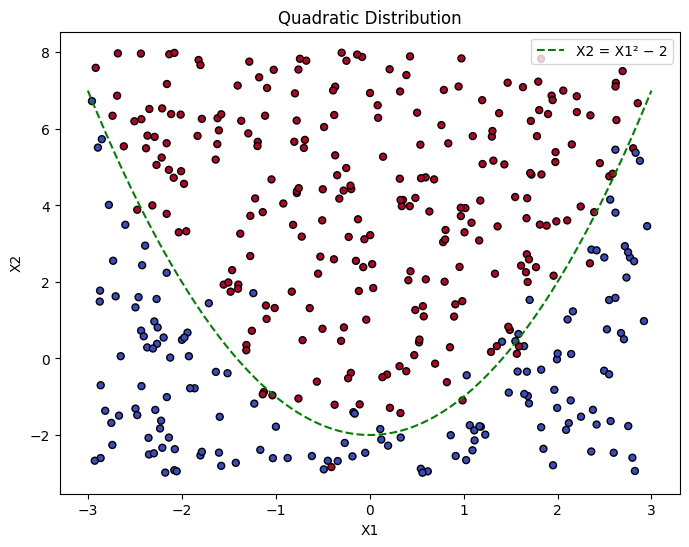

In [5]:
xs = np.linspace(-3, 3, 200)
plt.figure(figsize=(8, 6))
plt.scatter(data['X1'], data['X2'], c=data['Class'], cmap='coolwarm', edgecolors='k', s=25)
plt.plot(xs, xs**2 - 2, 'g--', label='X2 = X1² − 2')
plt.xlabel('X1'); plt.ylabel('X2'); plt.title('Quadratic Distribution'); plt.legend()
plt.show()

In [6]:
X = data[['X1', 'X2']]
y = data['Class']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

A linear kernel can only draw a straight line, so it can't follow the curve. It's shown here for comparison.

In [8]:
linear_model = make_pipeline(StandardScaler(), SVC(kernel='linear'))
linear_model.fit(X_train, y_train)
print(f"Linear kernel accuracy: {accuracy_score(y_test, linear_model.predict(X_test)):.4f}")

Linear kernel accuracy: 0.7875


A polynomial kernel with degree 2 can learn a quadratic decision boundary. coef0=1 adds the linear and constant terms, so the kernel covers the full X2 = aX1² + bX1 + c form.

In [9]:
model = make_pipeline(StandardScaler(), SVC(kernel='poly', degree=2, coef0=1, C=10))
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('svc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'poly'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",2
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'


In [10]:
predictions = model.predict(X_test)

In [11]:
print("Actual vs Predicted Class")
print("---------------------------")
comparison_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': predictions
})
print(comparison_df)

Actual vs Predicted Class
---------------------------
    Actual  Predicted
0        1          1
1        0          0
2        1          1
3        1          1
4        1          1
..     ...        ...
75       0          0
76       0          0
77       1          1
78       1          1
79       0          0

[80 rows x 2 columns]


In [12]:
acc = accuracy_score(y_test, predictions)

print("Classification Evaluation Metrics")
print("---------------------------")
print(f"Accuracy: {acc:.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions))
print("Classification Report:")
print(classification_report(y_test, predictions))

Classification Evaluation Metrics
---------------------------
Accuracy: 0.9250
Confusion Matrix:
[[29  4]
 [ 2 45]]
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.88      0.91        33
           1       0.92      0.96      0.94        47

    accuracy                           0.93        80
   macro avg       0.93      0.92      0.92        80
weighted avg       0.93      0.93      0.92        80



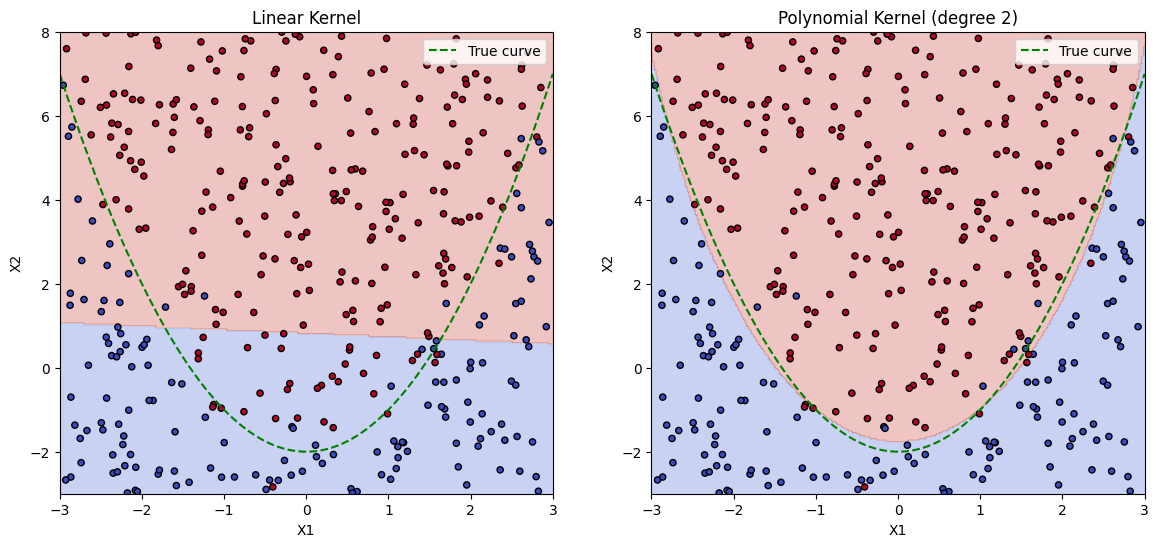

In [13]:
xx, yy = np.meshgrid(np.linspace(-3, 3, 300), np.linspace(-3, 8, 300))
grid = pd.DataFrame({'X1': xx.ravel(), 'X2': yy.ravel()})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, m, title in [(axes[0], linear_model, 'Linear Kernel'), (axes[1], model, 'Polynomial Kernel (degree 2)')]:
    zz = m.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, zz, alpha=0.3, cmap='coolwarm')
    ax.scatter(data['X1'], data['X2'], c=data['Class'], cmap='coolwarm', edgecolors='k', s=20)
    ax.plot(xs, xs**2 - 2, 'g--', label='True curve')
    ax.set_title(title); ax.set_xlabel('X1'); ax.set_ylabel('X2'); ax.legend()
plt.show()